In [1]:
import sys
sys.path.insert(0, "..")

from src.segmentation.dp import segment_dp
from src.segmentation.baseline import segment_baseline
from src.segmentation.metrics import compute_metrics, compare
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
TEXT = """
Large language models have billions of parameters and require significant
computational resources for inference. Techniques like quantization and
distillation help reduce inference costs substantially. Prompt engineering
has emerged as a key skill for working with these models effectively.
Retrieval-augmented generation combines LLMs with external knowledge sources
to improve factual accuracy. Fine-tuning on domain-specific data can
substantially improve performance on specialized tasks. Evaluation remains
a challenge, as automated metrics often fail to capture true quality.
The transformer architecture introduced self-attention mechanisms that allow
models to weigh the importance of different tokens dynamically. Unlike
recurrent networks, transformers process all tokens in parallel, which
dramatically reduces training time on modern hardware accelerators.
BERT leveraged bidirectional pre-training to achieve state-of-the-art results.
GPT models use a unidirectional autoregressive approach instead, making them
particularly well-suited for open-ended text generation tasks.
"""

In [3]:
dp_result = segment_dp(TEXT, lmin=30, lmax=150)
base_result = segment_baseline(TEXT, lmax=150)

report = compare(dp_result, base_result)

print(f"=== DP Optimal ===")
print(f"Segmentos:     {report.dp.num_segments}")
print(f"Costo total:   {report.dp.total_cost:,.0f}")
print(f"Avg tokens:    {report.dp.avg_tokens_per_segment}")
print(f"Std tokens:    {report.dp.std_tokens_per_segment}")

print(f"\n=== Baseline ===")
print(f"Segmentos:     {report.baseline.num_segments}")
print(f"Costo total:   {report.baseline.total_cost:,.0f}")
print(f"Avg tokens:    {report.baseline.avg_tokens_per_segment}")
print(f"Std tokens:    {report.baseline.std_tokens_per_segment}")

print(f"\n=== Comparación ===")
print(f"Reducción de costo: {report.cost_reduction_pct}%")
print(f"Diferencia en segmentos: {report.segment_diff}")

=== DP Optimal ===
Segmentos:     5
Costo total:   7,366
Avg tokens:    38.0
Std tokens:    5.4

=== Baseline ===
Segmentos:     2
Costo total:   23,882
Avg tokens:    95.0
Std tokens:    54.0

=== Comparación ===
Reducción de costo: 69.16%
Diferencia en segmentos: -3


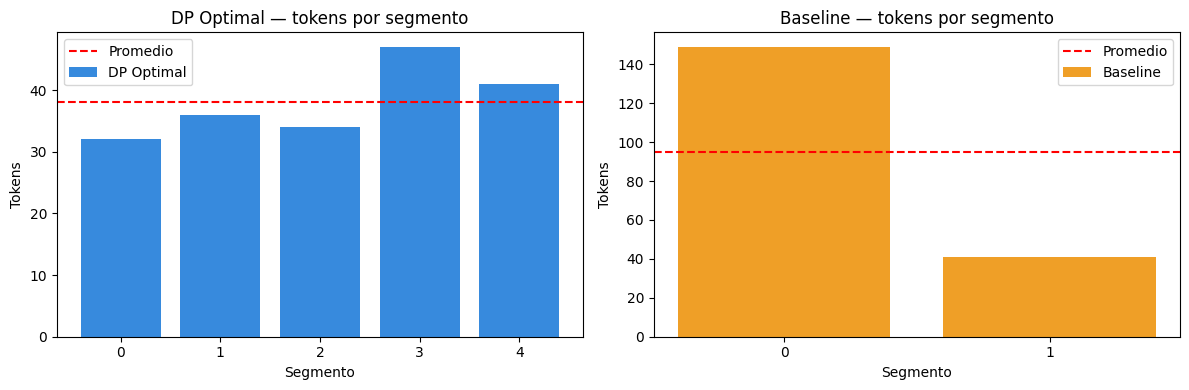

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dp_tokens = [s.token_count for s in dp_result.segments]
base_tokens = [s.token_count for s in base_result.segments]

axes[0].bar(range(len(dp_tokens)), dp_tokens, color="#378ADD", label="DP Optimal")
axes[0].set_title("DP Optimal — tokens por segmento")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("Tokens")
axes[0].set_xticks(range(len(dp_tokens)))
axes[0].axhline(y=report.dp.avg_tokens_per_segment, color="red", linestyle="--", label="Promedio")
axes[0].legend()

axes[1].bar(range(len(base_tokens)), base_tokens, color="#EF9F27", label="Baseline")
axes[1].set_title("Baseline — tokens por segmento")
axes[1].set_xlabel("Segmento")
axes[1].set_ylabel("Tokens")
axes[1].set_xticks(range(len(base_tokens)))
axes[1].axhline(y=report.baseline.avg_tokens_per_segment, color="red", linestyle="--", label="Promedio")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/comparison_tokens.png", dpi=150)
plt.show()

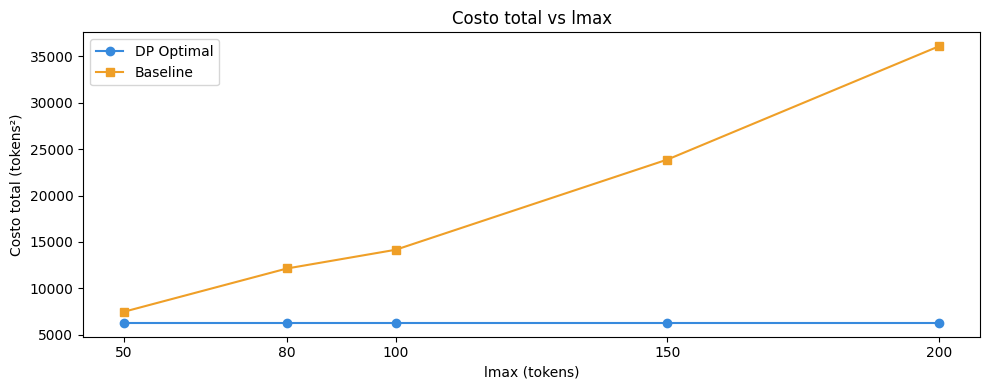


Reducción de costo por lmax:
  lmax=50: 16.06%
  lmax=80: 48.31%
  lmax=100: 55.68%
  lmax=150: 73.73%
  lmax=200: 82.62%


In [6]:
lmax_values = [50, 80, 100, 150, 200]
dp_costs = []
base_costs = []
reductions = []

for lmax in lmax_values:
    try:
        dp_r = segment_dp(TEXT, lmin=20, lmax=lmax)
        base_r = segment_baseline(TEXT, lmax=lmax)
        rep = compare(dp_r, base_r)
        dp_costs.append(rep.dp.total_cost)
        base_costs.append(rep.baseline.total_cost)
        reductions.append(rep.cost_reduction_pct)
    except ValueError as e:
        print(f"lmax={lmax} error: {e}")
        dp_costs.append(None)
        base_costs.append(None)
        reductions.append(None)

plt.figure(figsize=(10, 4))
plt.plot(lmax_values, dp_costs, marker="o", color="#378ADD", label="DP Optimal")
plt.plot(lmax_values, base_costs, marker="s", color="#EF9F27", label="Baseline")
plt.title("Costo total vs lmax")
plt.xlabel("lmax (tokens)")
plt.ylabel("Costo total (tokens²)")
plt.xticks(lmax_values)
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/cost_vs_lmax.png", dpi=150)
plt.show()

print("\nReducción de costo por lmax:")
for lmax, red in zip(lmax_values, reductions):
    print(f"  lmax={lmax}: {red}%")